In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cobra

In [2]:
# Load the results
results = pd.read_csv("fba_results.csv")

In [9]:
# Define light/dark cycles from the experiment
light_dark_cycles = [
    (0, 10),   # Light from 0 to 10 hours
    (10, 21),  # Dark from 10 to 21 hours
    (21, 34),  # Light from 21 to 34 hours
    (34, 46),  # Dark from 34 to 46 hours
]

In [4]:
# Load the model
model = cobra.io.read_sbml_model("../../../model.xml")

In [10]:
# Define the amount of carbon in the biomass metabolite
# From scripts/results/iHS4156_biomass_composition_work_table.csv
biomass_c = 42.94278526624263

In [5]:
# Get the growth rate (bio1_biomass) from each fluxes dictionary
results["fluxes"] = results["fluxes"].apply(eval)  # Convert string representation of dict to actual dict
results["growth_rate"] = results["fluxes"].apply(lambda x: x.get("bio1_biomass", 0))

In [6]:
results

,time_point,media,fluxes,growth_rate
0,0,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.003027508176484702, 'rxn0035...",0.470390
1,2,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.0028893296961019607, 'rxn003...",0.448921
2,4,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.0020500838945617067, 'rxn003...",0.318526
3,6,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.002563573452625028, 'rxn0035...",0.398308
4,8,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.0009712294155157149, 'rxn003...",0.150902
5,10,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.0021955044865086364, 'rxn003...",0.341120
6,12,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.003167581466566401, 'rxn0035...",0.492154
7,14,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.0026362006280842365, 'rxn003...",0.409592
8,16,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.0024005924522958197, 'rxn003...",0.372985
9,18,"{'EX_cpd00007_e0': 20, 'EX_cpd00013_e0': 1000,...","{'rxn02201_c0': 0.0009826633348660524, 'rxn003...",0.152678


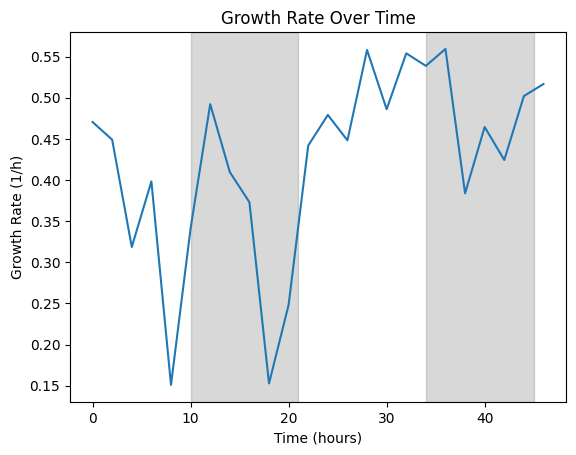

In [7]:
# Plot growth rate over time
plt.plot(results["time_point"], results["growth_rate"])
plt.xlabel("Time (hours)")
plt.ylabel("Growth Rate (1/h)")
plt.title("Growth Rate Over Time")

# Add shaded regions for the dark periods (every other period)
for i, (start, end) in enumerate(light_dark_cycles):
    if i % 2 == 1:  # Only shade dark periods (odd indices)
        plt.axvspan(start, end, color="gray", alpha=0.3)

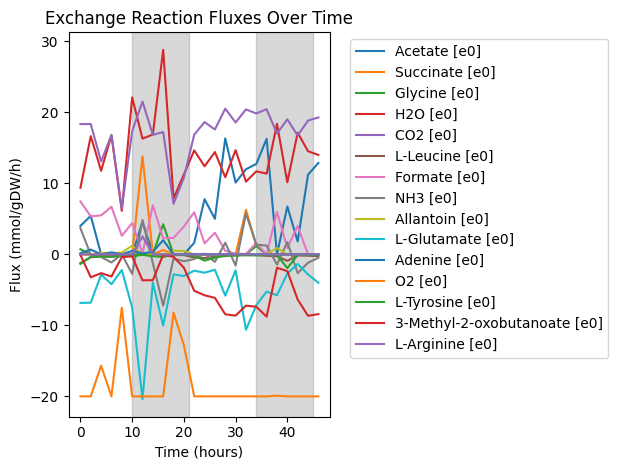

In [8]:
# Plot exchange reaction fluxes over time
# Extract exchange reactions from the "fluxes" column
exchange_fluxes = results["fluxes"].apply(lambda x: {k: v for k, v in x.items() if k.startswith("EX_")})
# Convert the list of dicts into a DataFrame
exchange_fluxes_df = pd.DataFrame(exchange_fluxes.tolist())
# Add the time points to the DataFrame
exchange_fluxes_df["time_point"] = results["time_point"]
# Plot the fluxes for exchange reactions with a absolute flux greater than 1 at any time point
for reaction in exchange_fluxes_df.columns[:-1]:  # Exclude the "time_point" column
    if exchange_fluxes_df[reaction].abs().max() > 1:
        plt.plot(exchange_fluxes_df["time_point"], exchange_fluxes_df[reaction], label=model.reactions.get_by_id(reaction).reactants[0].name)
plt.xlabel("Time (hours)")
plt.ylabel("Flux (mmol/gDW/h)")
plt.title("Exchange Reaction Fluxes Over Time")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Add shaded regions for the dark periods (every other period)
for i, (start, end) in enumerate(light_dark_cycles):
    if i % 2 == 1:  # Only shade dark periods (odd indices)
        plt.axvspan(start, end, color="gray", alpha=0.3)

In [31]:
# For each time point, calculate the total carbon uptake rate from the exchange fluxes
# Convert the exchange fluxes to carbon uptake rates by multiplying by the carbon content of the corresponding metabolite
carbon_fluxes = pd.DataFrame()
carbon_fluxes["time_point"] = exchange_fluxes_df["time_point"]
# First, we need to calculate the carbon uptake rate from the exchange fluxes
for reaction in exchange_fluxes_df.columns[:-1]:  # Exclude the "time_point" column
    # Get the corresponding metabolite for this exchange reaction
    met_id = reaction.replace("EX_", "")
    met = model.metabolites.get_by_id(met_id)
    # Get the number of carbon atoms in the metabolite
    carbon_content = met.elements['C'] if 'C' in met.elements else 0
    # Calculate the carbon flux and add it to the carbon fluxes DataFrame
    carbon_fluxes[reaction] = exchange_fluxes_df[reaction] * carbon_content
# For each timepoit (row) sum all of the negative carbon fluxes (uptake) to get the total carbon uptake rate
carbon_fluxes["total_carbon_uptake"] = carbon_fluxes.drop(columns=["time_point"]).apply(lambda x: x[x < 0].sum(), axis=1)

# Add a column with the carbon flux through the biomass reaction (growth rate * carbon content of biomass)
carbon_fluxes["biomass_carbon_flux"] = results["growth_rate"] * biomass_c

# Calculate yield as the ratio of biomass carbon flux to total carbon uptake
carbon_fluxes["yield"] = carbon_fluxes["biomass_carbon_flux"] / (abs(carbon_fluxes["total_carbon_uptake"]))  # Absolute value because uptake is negative flux

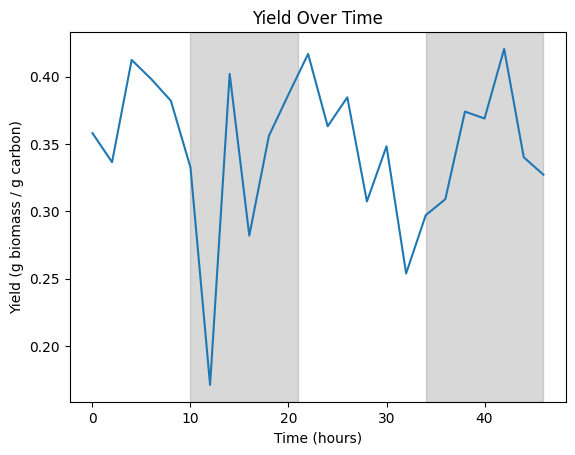

In [34]:
# Plot yield over time
plt.plot(carbon_fluxes["time_point"], carbon_fluxes["yield"])
plt.xlabel("Time (hours)")
plt.ylabel("Yield (g biomass / g carbon)")
plt.title("Yield Over Time")

# Add shaded regions for the dark periods (every other period)
for i, (start, end) in enumerate(light_dark_cycles):
    if i % 2 == 1:  # Only shade dark periods (odd indices)
        plt.axvspan(start, end, color="gray", alpha=0.3)